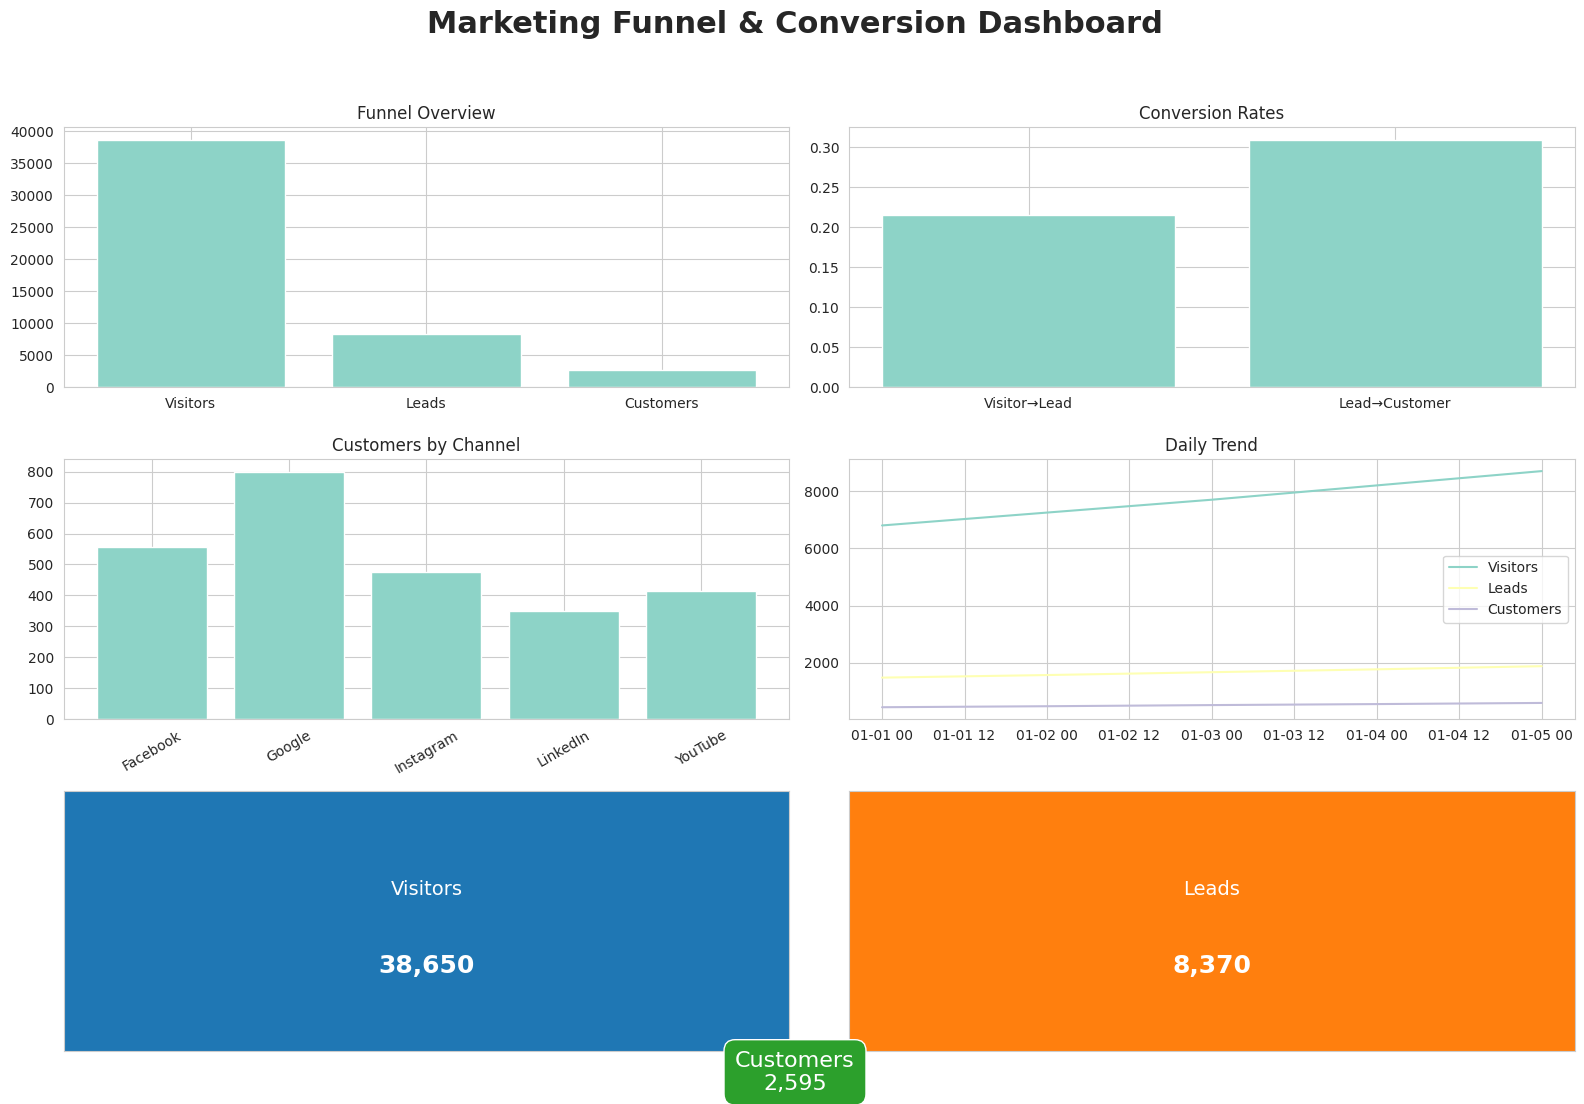

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("funnel_dataa.csv")
df['date'] = pd.to_datetime(df['date'])
df['visitor_to_lead'] = df['leads'] / df['visitors']
df['lead_to_customer'] = df['customers'] / df['leads']
total_visitors = df['visitors'].sum()
total_leads = df['leads'].sum()
total_customers = df['customers'].sum()
fig = plt.figure(figsize=(16,12))
fig.suptitle("Marketing Funnel & Conversion Dashboard", fontsize=22, fontweight='bold')

ax1 = plt.subplot(3,2,1)
ax2 = plt.subplot(3,2,2)
ax3 = plt.subplot(3,2,3)
ax4 = plt.subplot(3,2,4)


ax1.bar(['Visitors','Leads','Customers'],
        [total_visitors,total_leads,total_customers])
ax1.set_title("Funnel Overview")


ax2.bar(['Visitor→Lead','Lead→Customer'],
        [df['visitor_to_lead'].mean(), df['lead_to_customer'].mean()])
ax2.set_title("Conversion Rates")


channel = df.groupby('channel')['customers'].sum()
ax3.bar(channel.index, channel.values)
ax3.set_title("Customers by Channel")
ax3.tick_params(axis='x', rotation=30)

daily = df.groupby('date')[['visitors','leads','customers']].sum()
ax4.plot(daily.index, daily['visitors'], label='Visitors')
ax4.plot(daily.index, daily['leads'], label='Leads')
ax4.plot(daily.index, daily['customers'], label='Customers')
ax4.legend()
ax4.set_title("Daily Trend")
lines = ax4.get_lines()

def on_pick(event):
    line = event.artist
    visible = not line.get_visible()
    line.set_visible(visible)
    fig.canvas.draw()

for line in lines:
    line.set_picker(True)

fig.canvas.mpl_connect('pick_event', on_pick)


def kpi(ax, title, value, color):
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, title, ha='center', fontsize=14, color='white')
    ax.text(0.5, 0.3, f"{value:,}", ha='center', fontsize=18, color='white', fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

ax_kpi1 = plt.subplot(3,2,5)
ax_kpi2 = plt.subplot(3,2,6)


kpi(ax_kpi1, "Visitors", total_visitors, "#1f77b4")
kpi(ax_kpi2, "Leads", total_leads, "#ff7f0e")


fig.text(0.5, 0.08, f"Customers\n{total_customers:,}",
         ha='center', fontsize=16, color='white',
         bbox=dict(facecolor='#2ca02c', boxstyle='round,pad=0.5'))


plt.tight_layout(rect=[0,0.1,1,0.95])


plt.savefig("Final_Dashboard.png", dpi=300)

plt.show()
